# LangGraph Level 3C — Long-Term Memory with Store

Pattern covered:
1. **Store** — shared memory across different users and sessions

---
### Checkpointer vs Store — the key difference

| | Checkpointer (SQLite/Memory) | Store |
|---|---|---|
| **Scope** | Per thread (conversation) | Global: cross-thread, cross-user |
| **What it stores** | Graph state at each step | Facts, preferences, documents |
| **Access** | Only the thread that created it | Any thread can read/write |
| **When** | Conversation history | User profile, knowledge base |

```
Thread A (user Pedro) → saves a preference in the Store
Thread B (user Pedro, new session) → retrieves the preference from the Store
Thread C (user Ana) → saves her own preferences in the Store
```

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from typing import Literal, Annotated, TypedDict, Optional
import operator
import uuid
from IPython.display import Image, display

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.types import Command
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

---
## Store key concepts

The Store organizes memory in a **namespace** system:

```python
# namespace = tuple that acts like a folder
store.put(("users", "pedro"), key="profile", value={"role": "AI Engineer"})
#          ── namespace ──     ── key ──      ─────── value (dict) ──────

# Retrieve:
item = store.get(("users", "pedro"), key="profile")
item.value  # → {"role": "AI Engineer"}

# Search inside a namespace:
items = store.search(("users", "pedro"))  # all items for the user
```

**Node injection:** Nodes that need the store declare it as a `*, store: BaseStore` parameter.

---
## Demo 1 — Assistant that learns user preferences

The agent:
1. Reads the user's memory at the start of each conversation
2. Replies using the accumulated context
3. Extracts and stores new preferences at the end

In [4]:
class PersonalizedState(MessagesState):
    user_id: str
    memory_context: str  # what gets retrieved from the store

def load_user_memory(state: PersonalizedState, *, store: BaseStore) -> PersonalizedState:
    """At the start: load all of the user's memories from the Store."""
    namespace = ("user_memory", state["user_id"])
    memories = store.search(namespace)
    
    if memories:
        context = "What I know about this user:\n" + "\n".join(
            f"- {m.key}: {m.value.get('content', m.value)}"
            for m in memories
        )
    else:
        context = "First interaction — no prior history."
    
    print(f"[LoadMemory] User '{state['user_id']}' — {len(memories)} memories loaded")
    return {"memory_context": context}

def chat_with_context(state: PersonalizedState, *, store: BaseStore) -> PersonalizedState:
    """Replies using the user's memory context."""
    response = llm.invoke([
        SystemMessage(content=(
            f"You are a personalized AI assistant. "
            f"USER CONTEXT:\n{state['memory_context']}\n\n"
            f"Use this context to give personalized, relevant answers."
        )),
        *state["messages"]
    ])
    return {"messages": [response]}

def extract_and_save_memory(state: PersonalizedState, *, store: BaseStore) -> PersonalizedState:
    """At the end: extract relevant facts from the conversation and store them."""
    last_human = next((m.content for m in reversed(state["messages"]) if isinstance(m, HumanMessage)), "")
    
    # Extract a relevant fact
    extraction = llm.invoke([
        SystemMessage(content=(
            "Extract ONE concrete fact about the user from this message (preference, context, skill). "
            "If there is nothing relevant to remember, reply exactly with: 'NONE'. "
            "Format if there is something: 'FACT: [short description]'"
        )),
        HumanMessage(content=last_human)
    ])
    
    content = extraction.content.strip()
    if content != "NONE" and content.startswith("FACT:"):
        fact = content.replace("FACT:", "").strip()
        namespace = ("user_memory", state["user_id"])
        key = f"fact_{str(uuid.uuid4())[:8]}"
        store.put(namespace, key, {"content": fact})
        print(f"[SaveMemory] Saved: '{fact}'")
    else:
        print(f"[SaveMemory] Nothing to save")
    
    return {}

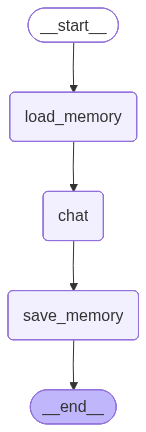

In [5]:
# Store: cross-session memory (persists across calls)
# Checkpointer: within-session memory (history of the current conversation)
long_term_store = InMemoryStore()
short_term_memory = InMemorySaver()

builder = StateGraph(PersonalizedState)
builder.add_node("load_memory", load_user_memory)
builder.add_node("chat", chat_with_context)
builder.add_node("save_memory", extract_and_save_memory)

builder.add_edge(START, "load_memory")
builder.add_edge("load_memory", "chat")
builder.add_edge("chat", "save_memory")
builder.add_edge("save_memory", END)

# Important: pass BOTH — store for long-term, checkpointer for short-term
personalized_graph = builder.compile(
    store=long_term_store,
    checkpointer=short_term_memory
)

display(Image(personalized_graph.get_graph().draw_mermaid_png()))

In [6]:
# ── SESSION 1 — first conversation ──────────────────────────────────────────
config_s1 = {"configurable": {"thread_id": "session-001"}}
user_id = "pedro"

print("=== SESSION 1 ===")

# Turn 1 — introduce context
r1 = personalized_graph.invoke({
    "messages": [HumanMessage(content="Hi, I'm an AI Engineer and I'm learning LangGraph for my contractor projects")],
    "user_id": user_id
}, config_s1)
print(f"AI: {r1['messages'][-1].content[:200]}")
print()

# Turn 2 — add more context
r2 = personalized_graph.invoke({
    "messages": [HumanMessage(content="I prefer Python implementations, I mostly work with FastAPI and PostgreSQL")],
    "user_id": user_id
}, config_s1)
print(f"AI: {r2['messages'][-1].content[:200]}")

=== SESSION 1 ===
[LoadMemory] User 'pedro' — 0 memories loaded
[SaveMemory] Saved: 'The user is an AI Engineer who is learning LangGraph for contractor projects.'
AI: Hi! Great to hear you're an AI Engineer learning LangGraph. It's a powerful tool for working with graphs and language models. Do you have any specific questions about Lang

[LoadMemory] User 'pedro' — 1 memories loaded
[SaveMemory] Saved: 'Prefers Python implementations and mostly works with FastAPI and PostgreSQL.'
AI: Perfect, FastAPI and PostgreSQL are great choices for building fast, efficient applications. LangGraph integrates well with these technologies. Here are a few ideas on how


In [7]:
# ── SESSION 2 — new session (new thread_id), but the Store remembers ─────────
config_s2 = {"configurable": {"thread_id": "session-002"}}  # different thread

print("=== SESSION 2 (new session, same user) ===")
print("The checkpointer has no history (new thread), but the Store does remember\n")

r3 = personalized_graph.invoke({
    "messages": [HumanMessage(content="Which LangGraph pattern would you recommend for my use case?")],
    "user_id": user_id  # same user_id → the Store loads the memories
}, config_s2)

print(f"AI: {r3['messages'][-1].content[:400]}")

# Inspect what's in the Store
memories = long_term_store.search(("user_memory", user_id))
print(f"\nMemory accumulated in the Store ({len(memories)} facts):")
for m in memories:
    print(f"  [{m.key}] {m.value.get('content', m.value)}")

=== SESSION 2 (new session, same user) ===
The checkpointer has no history (new thread), but the Store does remember

[LoadMemory] User 'pedro' — 2 memories loaded
[SaveMemory] Nothing to save
AI: Since you're an AI Engineer working with FastAPI and PostgreSQL, I'd recommend considering LangGraph's **GraphQL** pattern. It is especially useful for applications that need flexible data interaction, letting clients request only the information they need.

Here are a few reasons this pattern might be a good fit for you:

1. **Flexibi

Memory accumulated in the Store (2 facts):
  [fact_8ae9f55b] The user is an AI Engineer who is learning LangGraph for contractor projects.
  [fact_80eab973] Prefers Python implementations and mostly works with FastAPI and PostgreSQL.


---
## Demo 2 — Store as a shared knowledge base

The Store is not just for user profiles. It also serves as:
- Knowledge base shared across all agents
- Cache for expensive results
- Log of decisions taken

Here: multiple agents read and write a shared Store.

In [8]:
shared_store = InMemoryStore()

# Pre-load the knowledge base
KB_NAMESPACE = ("knowledge_base",)
shared_store.put(KB_NAMESPACE, "langgraph_overview", {
    "content": "LangGraph is a framework for building stateful applications with LLMs using directed graphs."
})
shared_store.put(KB_NAMESPACE, "langgraph_checkpointer", {
    "content": "LangGraph checkpointers persist state across invocations using thread_id."
})
shared_store.put(KB_NAMESPACE, "langgraph_store", {
    "content": "The LangGraph Store enables cross-thread and cross-user memory, ideal for profiles and knowledge bases."
})

class KBState(MessagesState):
    retrieved_context: str

def retrieve_from_kb(state: KBState, *, store: BaseStore) -> KBState:
    """Look up relevant context in the knowledge base."""
    user_query = state["messages"][-1].content
    
    # Simple text search (Store also supports semantic search with embeddings)
    all_docs = store.search(KB_NAMESPACE)
    # In production: store.search(namespace, query=user_query) with embeddings
    
    context = "Available documentation:\n" + "\n".join(
        f"- {doc.value['content']}" for doc in all_docs
    )
    print(f"[KB Retrieval] {len(all_docs)} documents retrieved")
    return {"retrieved_context": context}

def answer_with_kb(state: KBState) -> KBState:
    """Answer using the retrieved context."""
    response = llm.invoke([
        SystemMessage(content=f"Answer based ONLY on this documentation:\n{state['retrieved_context']}"),
        *state["messages"]
    ])
    return {"messages": [response]}

kb_builder = StateGraph(KBState)
kb_builder.add_node("retrieve", retrieve_from_kb)
kb_builder.add_node("answer", answer_with_kb)
kb_builder.add_edge(START, "retrieve")
kb_builder.add_edge("retrieve", "answer")
kb_builder.add_edge("answer", END)

kb_graph = kb_builder.compile(store=shared_store)

result = kb_graph.invoke({
    "messages": [HumanMessage(content="What's the difference between checkpointer and Store in LangGraph?")]
})
print(result["messages"][-1].content)

[KB Retrieval] 3 documents retrieved
The difference between checkpointer and Store in LangGraph comes down to their function and use:

- **Checkpointer**: Persists state across invocations using a `thread_id`. This is useful for keeping the state of a specific conversation or process within a single execution thread.

- **Store**: Provides cross-thread and cross-user memory, making it ideal for storing information like profiles and knowledge bases that can be accessed from different threads and users.

In short, the checkpointer focuses on persisting state within a specific context, whereas the Store focuses on shared memory accessible across multiple threads and users.


---
## Quick reference — Store operations

```python
store = InMemoryStore()

# WRITE — save
store.put(("users", user_id), key="profile", value={"name": "Pedro", "role": "AI Eng"})

# READ — read a specific item
item = store.get(("users", user_id), key="profile")
item.value   # → {"name": "Pedro", ...}
item.key     # → "profile"

# SEARCH — all items in a namespace
items = store.search(("users", user_id))
# With semantic search (requires embeddings configured):
# items = store.search(("users", user_id), query="work preferences", limit=5)

# DELETE — remove
store.delete(("users", user_id), key="profile")

# NAMESPACES — isolate by entity
# ("users", "pedro")     → Pedro's data
# ("users", "ana")       → Ana's data (isolated)
# ("knowledge_base",)    → shared by everyone
# ("cache", "responses") → response cache
```

---
## Takeaways — N3C

**Store is long-term memory, Checkpointer is short-term memory:**
- Combine them: `graph.compile(store=store, checkpointer=checkpointer)`
- The checkpointer handles conversation history within a thread
- The Store persists knowledge across threads and sessions

**Injection pattern:** Nodes that need the Store declare it as `*, store: BaseStore`
- LangGraph injects the Store automatically when compiled with `store=`
- The Store is the same for every node in the graph

**Real use cases:**
- User profile that evolves across sessions
- Knowledge base shared by specialist agents
- Cache for expensive results (embeddings, external API calls)
- Log of past decisions to avoid repeating them

**In production:** swap `InMemoryStore` for `PostgresStore` for real persistence without changing node code.